In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from scipy.io import arff


In [5]:
data = arff.loadarff('/content/drive/MyDrive/Hasan sir/new_analysis_prediction/albrecht.arff')
df = pd.DataFrame(data[0])
df.head()

,Input,Output,Inquiry,File,FPAdj,RawFPcounts,AdjFP,Effort
0,25.0,150.0,75.0,60.0,1.00,1750.00,1750.0,102.4
1,193.0,98.0,70.0,36.0,1.00,1902.00,1902.0,105.2
2,70.0,27.0,0.0,12.0,0.80,535.00,428.0,11.1
3,40.0,60.0,20.0,12.0,1.15,660.00,759.0,21.1
4,10.0,69.0,1.0,9.0,0.90,478.89,431.0,28.8


In [6]:
df.describe()

,Input,Output,Inquiry,File,FPAdj,RawFPcounts,AdjFP,Effort
count,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,40.250000,47.250000,16.875000,17.375000,0.989583,638.539583,647.625000,21.875000
std,36.913824,35.169466,19.337534,15.522249,0.135116,452.653542,487.995261,28.417895
min,7.000000,12.000000,0.000000,3.000000,0.750000,189.520000,199.000000,0.500000
25%,23.000000,18.500000,3.250000,5.750000,0.887500,347.397500,287.500000,7.150000
50%,33.500000,39.000000,13.500000,11.500000,1.000000,489.105000,506.000000,11.450000
75%,43.500000,64.500000,20.250000,22.250000,1.100000,699.447500,710.250000,19.525000
max,193.000000,150.000000,75.000000,60.000000,1.200000,1902.000000,1902.000000,105.200000


<Axes: title={'center': 'Pearson Correlation of Features'}>

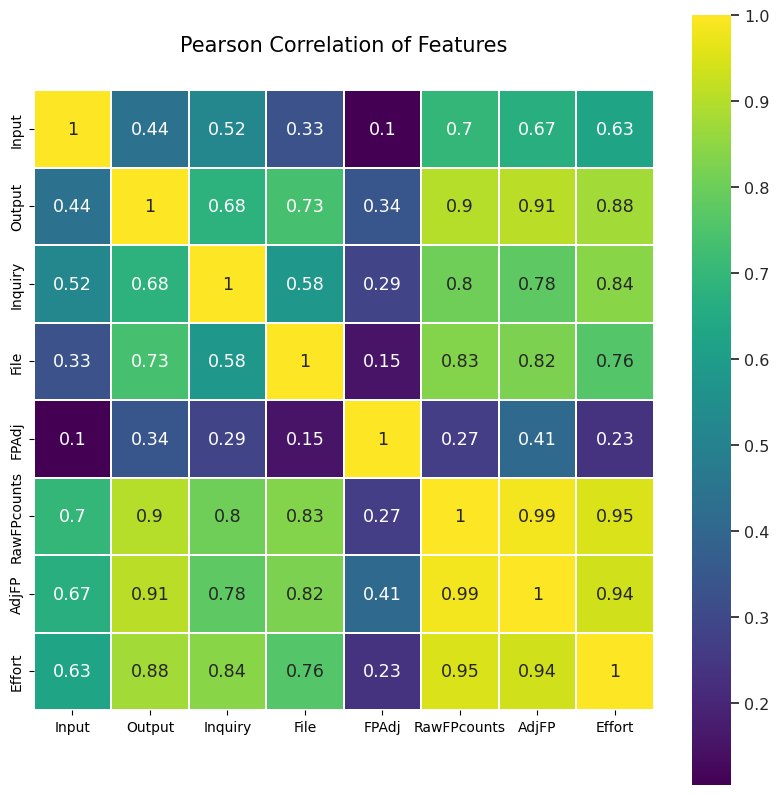

In [7]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [8]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.6])

,0
AdjFP,0.985709
RawFPcounts,0.985709
Effort,0.949967
Output,0.906449
Inquiry,0.840994
File,0.834685
Input,0.697841


In [9]:
#features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities','PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['RawFPcounts', 'AdjFP', 'Effort','Output','Inquiry', 'File','Input']

X = df[max_corr_features]
y = df['Effort']

In [10]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [11]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=9, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict_knn = neigh.predict(X_Test)
#print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_knn)))
#print("Mean Absolute error", mean_absolute_error(Y_Test, predict_knn))

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [14]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_knn)
mse = mean_squared_error(Y_Test, predict_knn)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_knn)
mape = mean_absolute_percentage_error(Y_Test, predict_knn)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 18.26
Mean Squared Error (MSE): 937.24
Root Mean Squared Error (RMSE): 30.61
R-squared (R²): 0.10
mape: 184.36


In [15]:
import matplotlib.pyplot as plot
import pandas

In [16]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

In [17]:
Y_Train.shape

(16,)

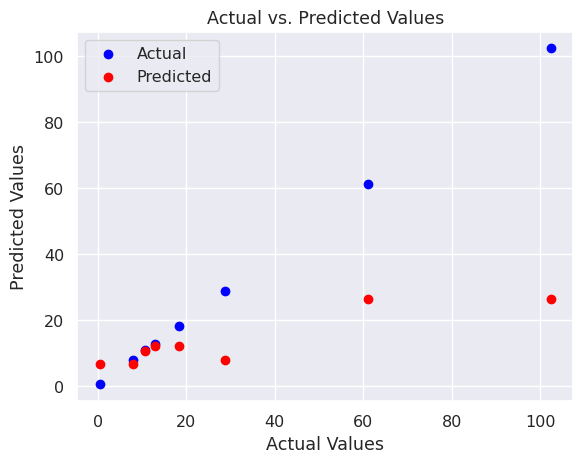

In [18]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [21]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict_LR = regressor.predict(X_Test)
#print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LR)))
#print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LR))

In [22]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [23]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LR)
mse = mean_squared_error(Y_Test, predict_LR)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LR)
mape = mean_absolute_percentage_error(Y_Test, predict_LR)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.00
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R-squared (R²): 1.00
mape: 0.00


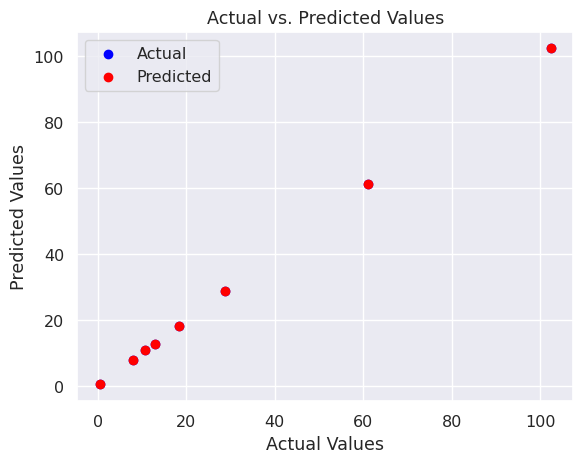

In [24]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LR             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***RandomForestRegressor***

In [25]:
regressor = RandomForestRegressor(n_estimators=100,max_features=5)
regressor.fit(X_Train, Y_Train)
predict_RF = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_RF)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_RF))

Root mean square:  13.273494942930453
Mean Absolute error 8.492750000000004


In [26]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [27]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 8.49
Mean Squared Error (MSE): 176.19
Root Mean Squared Error (RMSE): 13.27
R-squared (R²): 0.83
mape: 108.62


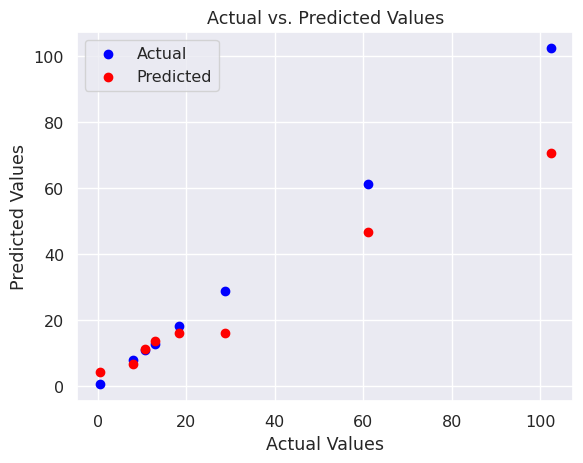

In [28]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_RF             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

In [29]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [30]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 8.49
Mean Squared Error (MSE): 176.19
Root Mean Squared Error (RMSE): 13.27
R-squared (R²): 0.83
mape: 108.62


# ***SVM***

In [31]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_Train, Y_Train)
predict_SVM = LinearSVC.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_SVM)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_SVM))

Root mean square:  0.47068044942623355
Mean Absolute error 0.3159935565364813


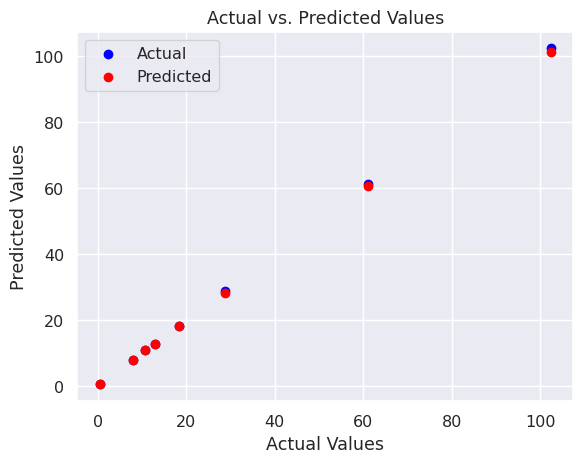

In [32]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_SVM             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

In [33]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [34]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_SVM)
mse = mean_squared_error(Y_Test, predict_SVM)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_SVM)
mape = mean_absolute_percentage_error(Y_Test, predict_SVM)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.32
Mean Squared Error (MSE): 0.22
Root Mean Squared Error (RMSE): 0.47
R-squared (R²): 1.00
mape: 1.65


# ***lasso***

In [35]:
from sklearn import linear_model

In [36]:
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_Train, Y_Train)
print(clf.coef_)
print(clf.intercept_)
# make a prediction
predict_LS = clf.predict(X_Test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LS)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LS))

[ 0.06063586 -0.          0.99691906 -0.30234462 -0.23929933 -0.60511341
 -0.24234229]
-0.05895812302427572
Root mean square:  0.049343063809549476
Mean Absolute error 0.041645677851002816


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.964e+00, tolerance: 9.342e-01
  model = cd_fast.enet_coordinate_descent(


In [37]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [38]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LS)
mse = mean_squared_error(Y_Test, predict_LS)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LS)
mape = mean_absolute_percentage_error(Y_Test, predict_LS)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 0.04
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.05
R-squared (R²): 1.00
mape: 0.47


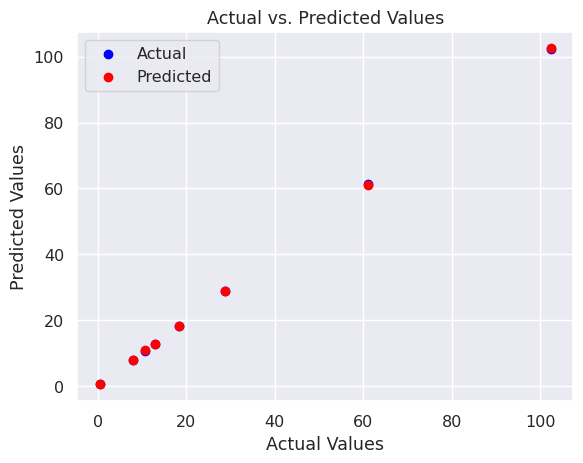

In [39]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LS             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()